In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/car_data_cleaned.csv")
print("Loaded shape:", df.shape)

df['Car_Age'] = 2020 - df['Year']
df_reference = df.copy()
df_model = df.drop(columns=['Car_Name', 'Year'])
df_model = pd.get_dummies(df_model, columns=['Fuel_Type', 'Selling_type', 'Transmission'], drop_first=True)

print("Model-ready shape:", df_model.shape)
df_model.head()

Loaded shape: (198, 9)
Model-ready shape: (198, 9)


,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,6,False,True,False,True
1,4.75,9.54,43000,0,7,True,False,False,True
2,7.25,9.85,6900,0,3,False,True,False,True
3,2.85,4.15,5200,0,9,False,True,False,True
4,4.60,6.87,42450,0,6,True,False,False,True


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df_model.drop(columns=['Selling_Price'])
y = df_model['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f} lakhs")
print(f"RMSE: {rmse:.2f} lakhs")
print(f"R²: {r2:.3f}")

Training set size: (158, 8)
Test set size: (40, 8)
MAE: 1.42 lakhs
RMSE: 2.62 lakhs
R²: 0.797


In [6]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []

for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = mean_squared_error(y_test, pred) ** 0.5
    r2 = r2_score(y_test, pred)
    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})

results_df = pd.DataFrame(results)
print(results_df)

               Model       MAE      RMSE        R2
0  Linear Regression  1.421977  2.616480  0.797140
1      Random Forest  1.099618  2.651596  0.791658
2  Gradient Boosting  1.146597  2.799311  0.767799


In [7]:
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='r2')

print("Cross-validation R² scores:", cv_scores)
print(f"Mean R²: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

Cross-validation R² scores: [0.90809029 0.85507915 0.74323204 0.90199641 0.85045669]
Mean R²: 0.852 (+/- 0.059)


In [8]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validated R²:", grid_search.best_score_)

Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best cross-validated R²: 0.8886069617280447


In [9]:
final_model = grid_search.best_estimator_

y_pred_final = final_model.predict(X_test)

mae_final = mean_absolute_error(y_test, y_pred_final)
rmse_final = mean_squared_error(y_test, y_pred_final) ** 0.5
r2_final = r2_score(y_test, y_pred_final)

print(f"Final Tuned Random Forest — Test Set Performance:")
print(f"MAE: {mae_final:.2f} lakhs")
print(f"RMSE: {rmse_final:.2f} lakhs")
print(f"R²: {r2_final:.3f}")


Final Tuned Random Forest — Test Set Performance:
MAE: 1.10 lakhs
RMSE: 2.59 lakhs
R²: 0.801


                   Feature  Importance
0            Present_Price    0.800278
3                  Car_Age    0.144240
1               Driven_kms    0.049045
4         Fuel_Type_Diesel    0.002371
5         Fuel_Type_Petrol    0.002133
7      Transmission_Manual    0.001385
6  Selling_type_Individual    0.000471
2                    Owner    0.000078


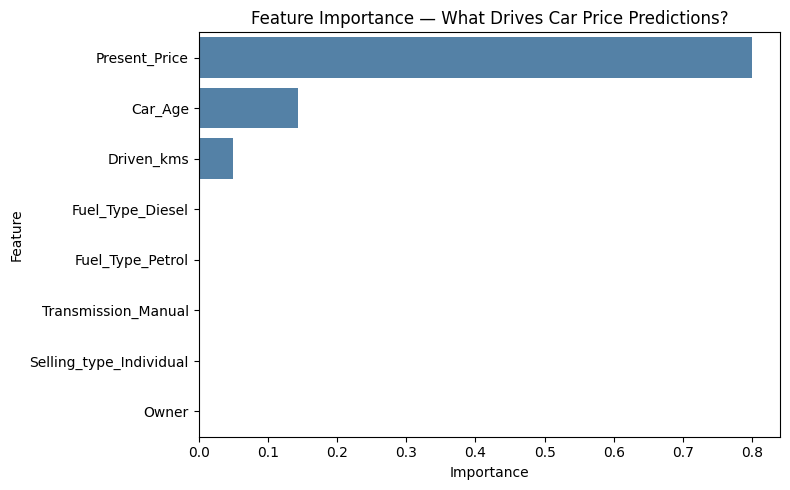

In [10]:
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importances)

plt.figure(figsize=(8, 5))
sns.barplot(data=importances, x='Importance', y='Feature', color='steelblue')
plt.title('Feature Importance — What Drives Car Price Predictions?')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../visualizations/01_feature_importance.png', dpi=150)
plt.show()

In [11]:
# Add predictions and errors to a results dataframe, keeping Car_Name for context
test_indices = X_test.index
error_df = df_reference.loc[test_indices].copy()
error_df['Predicted_Price'] = y_pred_final
error_df['Actual_Price'] = y_test.values
error_df['Error'] = error_df['Predicted_Price'] - error_df['Actual_Price']
error_df['Abs_Error'] = error_df['Error'].abs()

error_df_sorted = error_df.sort_values('Abs_Error', ascending=False)
print(error_df_sorted[['Car_Name', 'Actual_Price', 'Predicted_Price', 'Error']].head(10))

          Car_Name  Actual_Price  Predicted_Price     Error
85    land cruiser         35.00         20.12245 -14.87755
82          innova         12.50          9.10165  -3.39835
147          creta         12.90         10.14940  -2.75060
65          innova         19.75         17.28240  -2.46760
76         corolla          1.50          3.41975   1.91975
73     etios cross          4.90          6.73330   1.83330
68   corolla altis         14.25         15.95980   1.70980
56   corolla altis          4.75          6.19950   1.44950
175           jazz          6.00          7.18640   1.18640
119            i20          6.00          4.92825  -1.07175


In [12]:
# Performance excluding the Land Cruiser outlier
mask = error_df_sorted.index != error_df_sorted.index[0]
mae_no_outlier = error_df_sorted.loc[mask, 'Abs_Error'].mean()
print(f"MAE excluding Land Cruiser outlier: {mae_no_outlier:.2f} lakhs")
print(f"MAE including Land Cruiser outlier: {mae_final:.2f} lakhs")

MAE excluding Land Cruiser outlier: 0.75 lakhs
MAE including Land Cruiser outlier: 1.10 lakhs


In [13]:
import joblib

joblib.dump(final_model, '../data/processed/car_price_model.pkl')
X.columns.to_series().to_csv('../data/processed/model_features.csv', index=False)

print("Model and feature list saved successfully.")

Model and feature list saved successfully.


In [14]:
# Set a consistent, professional style for all charts in this project
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

PRIMARY_COLOR = '#2563eb'
SECONDARY_COLOR = '#dc2626'
ACCENT_COLOR = '#16a34a'

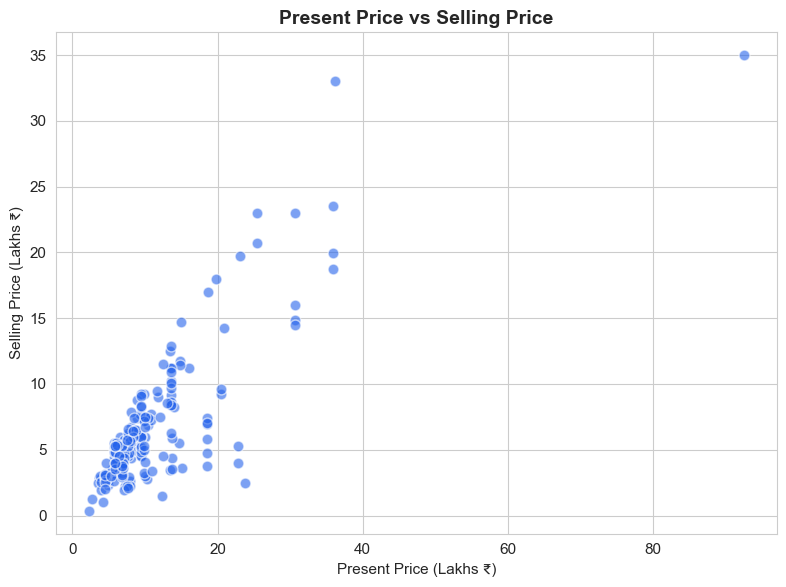

In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(df_reference['Present_Price'], df_reference['Selling_Price'], 
            color=PRIMARY_COLOR, alpha=0.6, edgecolor='white', s=60)
plt.title('Present Price vs Selling Price')
plt.xlabel('Present Price (Lakhs ₹)')
plt.ylabel('Selling Price (Lakhs ₹)')
plt.tight_layout()
plt.savefig('../visualizations/02_present_vs_selling_price.png', dpi=150)
plt.show()

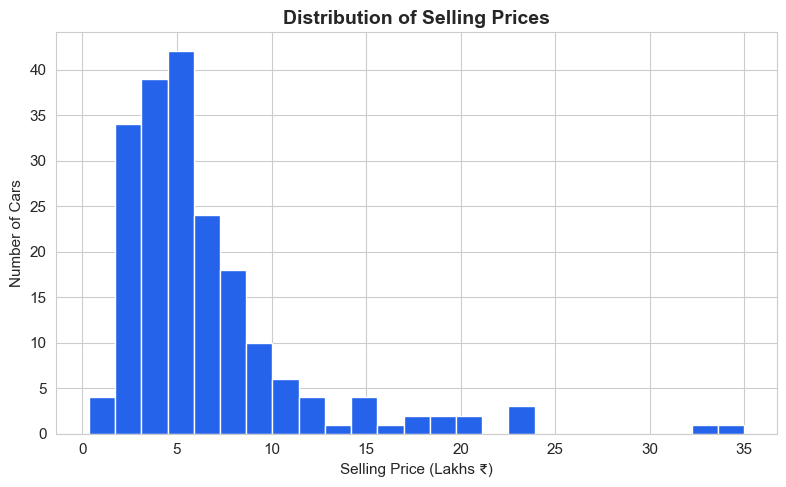

In [16]:
plt.figure(figsize=(8, 5))
plt.hist(df_reference['Selling_Price'], bins=25, color=PRIMARY_COLOR, edgecolor='white')
plt.title('Distribution of Selling Prices')
plt.xlabel('Selling Price (Lakhs ₹)')
plt.ylabel('Number of Cars')
plt.tight_layout()
plt.savefig('../visualizations/03_price_distribution.png', dpi=150)
plt.show()

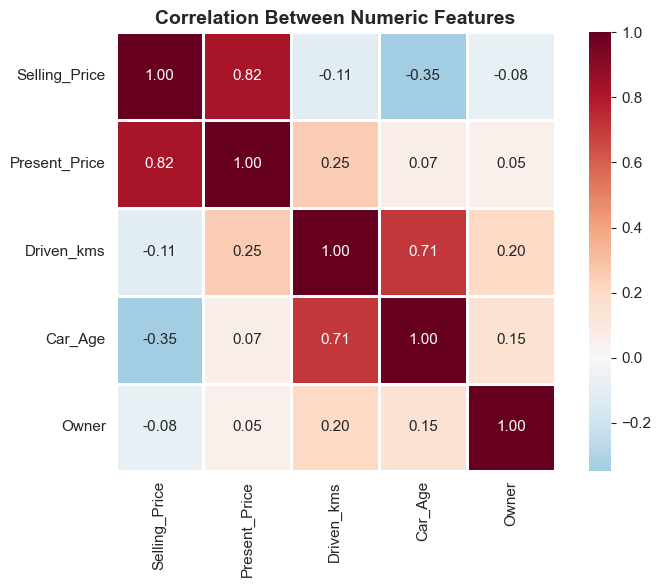

In [17]:
plt.figure(figsize=(8, 6))
corr_cols = ['Selling_Price', 'Present_Price', 'Driven_kms', 'Car_Age', 'Owner']
corr_matrix = df_reference[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            square=True, linewidths=1)
plt.title('Correlation Between Numeric Features')
plt.tight_layout()
plt.savefig('../visualizations/04_correlation_heatmap.png', dpi=150)
plt.show()

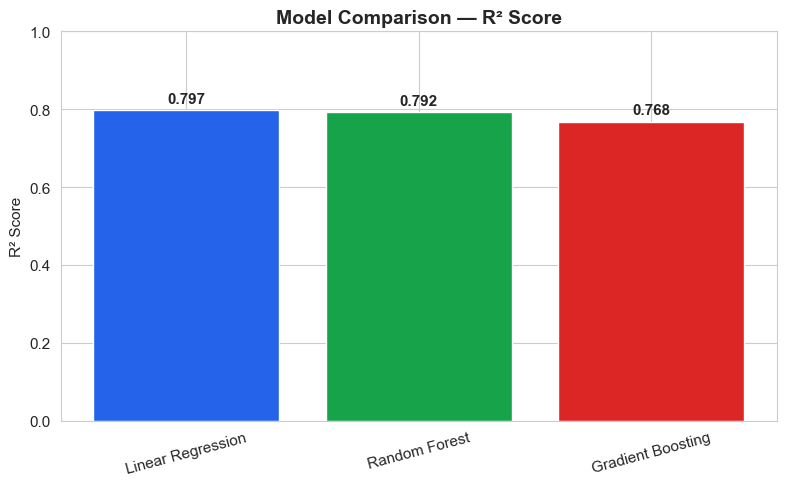

In [18]:
plt.figure(figsize=(8, 5))
x_pos = np.arange(len(results_df))
plt.bar(x_pos, results_df['R2'], color=[PRIMARY_COLOR, ACCENT_COLOR, SECONDARY_COLOR])
plt.xticks(x_pos, results_df['Model'], rotation=15)
plt.title('Model Comparison — R² Score')
plt.ylabel('R² Score')
plt.ylim(0, 1)
for i, v in enumerate(results_df['R2']):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../visualizations/05_model_comparison.png', dpi=150)
plt.show()